In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# FMCW Radar Mutual Interference: Victim and Interferer Analysis

## Introduction

This notebook demonstrates **radar-to-radar interference**—a critical challenge in automotive radar where multiple nearby vehicles operate similar radar systems simultaneously. As automotive radar adoption increases (76-81 GHz band), multiple radars create a congested electromagnetic environment where interference corrupts target detection.

### Interference Mechanisms

When victim radar receives interferer's signal:

1. **Direct Reception**: Victim RX picks up interferer TX
2. **Beat Frequency**: Mixing creates baseband interference
3. **False Targets**: Interference appears at incorrect ranges

**Interference Power:**

$$P_{int} = P_t G_t G_r \left(\frac{\lambda}{4\pi R}\right)^2$$

**Critical Factor:** Radar-to-radar interference is often **much stronger** than target returns because interferer directly illuminates victim (1/R² loss vs. target's 1/R⁴).

**Mitigation Strategies:**
- **Frequency Hopping**: Change carrier per chirp (used in this example)
- **Random PRP**: Avoid synchronization
- **Signal Processing**: Interference detection, blanking, CFAR with rejection

### This Example

This notebook uses [`RadarSimPy`](https://radarsimx.com/radarsimx/radarsimpy/) to simulate:

**Victim Radar:**
- Down-chirp: 60.6 → 60.4 GHz (200 MHz BW)
- 4 chirps with frequency diversity (90 MHz steps)
- PRP: 20 μs, Pulse width: 16 μs
- Located at origin, facing +X

**Interfering Radar:**
- Up-chirp: 60.4 → 60.6 GHz (opposite slope)
- 8 chirps with frequency diversity (70 MHz steps)
- PRP: 11 μs, Pulse width: 8 μs
- Located at (30, 0, 0) m, facing -X (towards victim)

**Processing:**
- Simulate victim radar with interference
- Extract clean baseband and interference component separately
- Visualize chirp timing and baseband corruption

## Interfering Radar Configuration

Configure the interfering radar that will cause interference to the victim radar.

In [2]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))


### Interfering Radar Configuration ###

# Frequency offsets for frequency diversity (8 chirps)
f_offset_int = np.arange(0, 8) * 70e6  # [0, 70, 140, ..., 490] MHz

# Configure interfering radar transmitter
int_tx = Transmitter(
    f=[60.4e9, 60.6e9],     # Frequency sweep: 60.4-60.6 GHz (200 MHz BW, up-chirp)
    t=[0, 8e-6],            # Chirp duration: 8 μs
    tx_power=15,            # Transmit power: 15 dBm (~32 mW)
    prp=11e-6,              # Pulse repetition period: 11 μs (90.9 kHz PRF)
    pulses=8,               # Number of chirps: 8
    f_offset=f_offset_int,  # Frequency diversity: different carrier per chirp
    channels=[
        dict(
            location=(0, 0.1, 0),
            pulse_phs=np.array([0, 0, 180, 0, 0, 0, 0, 0])
        )
    ],
)

# Configure interfering radar receiver
int_rx = Receiver(
    fs=20e6,
    noise_figure=8,
    rf_gain=20,
    load_resistor=500,
    baseband_gain=30,
    channels=[dict(location=(0, 0.1, 0))],
)

# Create interfering radar system
# Location: (30, 0, 0) m → 30m from victim
# Rotation: (180, 0, 0) deg → Facing -X direction (towards victim)
int_radar = Radar(
    transmitter=int_tx, 
    receiver=int_rx, 
    location=(30, 0, 0),
    rotation=(180, 0, 0)
)

## Victim Radar Configuration

Configure the victim radar that will experience interference from the interfering radar.

**Key Differences from Interferer:**

| Parameter | Victim | Interferer |
|-----------|--------|------------|
| Chirp Direction | Down (60.6 → 60.4 GHz) | Up (60.4 → 60.6 GHz) |
| Pulse Width | 16 μs | 8 μs |
| PRF | 50 kHz (20 μs PRP) | 90.9 kHz (11 μs PRP) |
| Pulse Count | 4 | 8 |
| Frequency Hop | 90 MHz steps | 70 MHz steps |
| Power | 25 dBm | 15 dBm |

Both radars use frequency hopping to reduce interference probability, but with overlapping bands (60.4-60.6 GHz), collisions are inevitable when chirps overlap temporally.

In [3]:
### Victim Radar Configuration ###

# Frequency offsets for frequency diversity (4 chirps)
# Each chirp hops to different frequency band (90 MHz steps)
f_offset_vit = np.arange(0, 4) * 90e6  # [0, 90, 180, 270] MHz

# Configure victim radar transmitter
tx = Transmitter(
    f=[60.6e9, 60.4e9],     # Frequency sweep: 60.6-60.4 GHz (200 MHz BW, down-chirp)
    t=[0, 16e-6],           # Chirp duration: 0-16 μs (longer than interferer)
    tx_power=25,            # Transmit power: 25 dBm (~316 mW, higher than interferer)
    prp=20e-6,              # Pulse repetition period: 20 μs (50 kHz PRF)
    pulses=4,               # Number of chirps: 4 (fewer than interferer)
    f_offset=f_offset_vit,  # Frequency diversity: different carrier per chirp
    channels=[
        dict(
            location=(0, 0, 0),  # Antenna position: at origin
            pulse_phs=np.array([180, 0, 0, 0])  # Phase coding: first chirp 180°
        )
    ],
)

# Configure victim radar receiver
rx = Receiver(
    fs=40e6,             # Sampling rate: 40 MHz (higher than interferer)
    noise_figure=2,      # Noise figure: 2 dB (lower noise, better sensitivity)
    rf_gain=20,          # RF gain: 20 dB
    load_resistor=500,   # Load resistance: 500 Ω
    baseband_gain=60,    # Baseband gain: 60 dB (higher than interferer)
    channels=[dict(location=(0, 0, 0))],  # Receiver antenna at origin
)

# Create victim radar system
# Location: (0, 0, 0) m → At origin
# Rotation: (0, 0, 0) deg → Facing +X direction (default)
radar = Radar(transmitter=tx, receiver=rx)

## Target Configuration

Define two point targets for the victim radar to detect while experiencing interference.

**Target Parameters:**

| Target | Location (m) | Velocity (m/s) | RCS (dBsm) | Scenario |
|--------|--------------|----------------|------------|----------|
| 1 | (30, 0, 0) | (0, 0, 0) | 10 | Stationary at interferer location |
| 2 | (20, 1, 0) | (-10, 0, 0) | 10 | Approaching vehicle |

The victim radar must detect these legitimate targets while being corrupted by interference from the radar at the same location as Target 1.

In [4]:
# Configure Target 1: Stationary at interferer location
target_1 = dict(
    location=(30, 0, 0),  # Position: 30m (co-located with interfering radar)
    speed=(0, 0, 0),      # Velocity: stationary
    rcs=10,               # Radar cross section: 10 dBsm
    phase=0,              # Initial phase: 0 degrees
)

# Configure Target 2: Moving vehicle
target_2 = dict(
    location=(20, 1, 0),  # Position: 20m range, 1m Y-offset
    speed=(-10, 0, 0),    # Velocity: -10 m/s (approaching)
    rcs=10,               # Radar cross section: 10 dBsm
    phase=0,              # Initial phase: 0 degrees
)

# Combine targets for simulation
targets = [target_1, target_2]

## Radar Interference Simulation

Simulate victim radar operation with interference from the interfering radar.

**Interference Modeling:**

The `interf` parameter in `sim_radar` enables mutual interference simulation:
- Computes when victim RX receives interferer TX
- Calculates interference power (1/R² propagation)
- Generates beat frequencies from chirp mixing
- Adds interference to victim baseband

**Output Structure:**

The simulation returns three separate components:
1. **baseband**: Clean target returns (no interference)
2. **interference**: Pure interference signal
3. **Total**: baseband + interference (realistic scenario)

**Data Dimensions:**
- **Channels**: 1 (single victim TX/RX)
- **Pulses**: 4 (victim radar chirps)
- **Samples**: 640 per chirp (40 MHz × 16 μs)

In [5]:
# Import radar simulator and timing module
from radarsimpy.simulator import sim_radar
import time

# Start timing
tic = time.time()

# Simulate victim radar with interference from interfering radar
# interf=int_radar: Links interfering radar to victim for mutual interference
bb_data = sim_radar(radar, targets, interf=int_radar)

# Extract simulation outputs
timestamp = bb_data["timestamp"]        # Time axis for each sample [1, 4, 640]
baseband = bb_data["baseband"]          # Clean target returns (no interference)
interf = bb_data["interference"]        # Pure interference component

# Combine clean and interference for realistic scenario
interf_bb = baseband + interf           # Total baseband with interference

# End timing
toc = time.time()
print("Exec time:", toc - tic, "s")

Exec time: 0.1097559928894043 s


## Visualization: Chirp Timing and Interference Impact

Visualize chirp timing relationships and resulting baseband corruption.

**Two-Panel Visualization:**

**Panel 1: Time-Frequency Diagram**
- **Victim chirps** (blue): 4 down-chirps with frequency hopping
- **Interferer chirps** (orange): 8 up-chirps with frequency hopping
- **Overlap regions**: Where interference corruption occurs

**Panel 2: Interfered Baseband**
- **Real part** (teal): In-phase component
- **Imaginary part** (purple): Quadrature component
- **Corruption visible**: Amplitude spikes during chirp overlaps

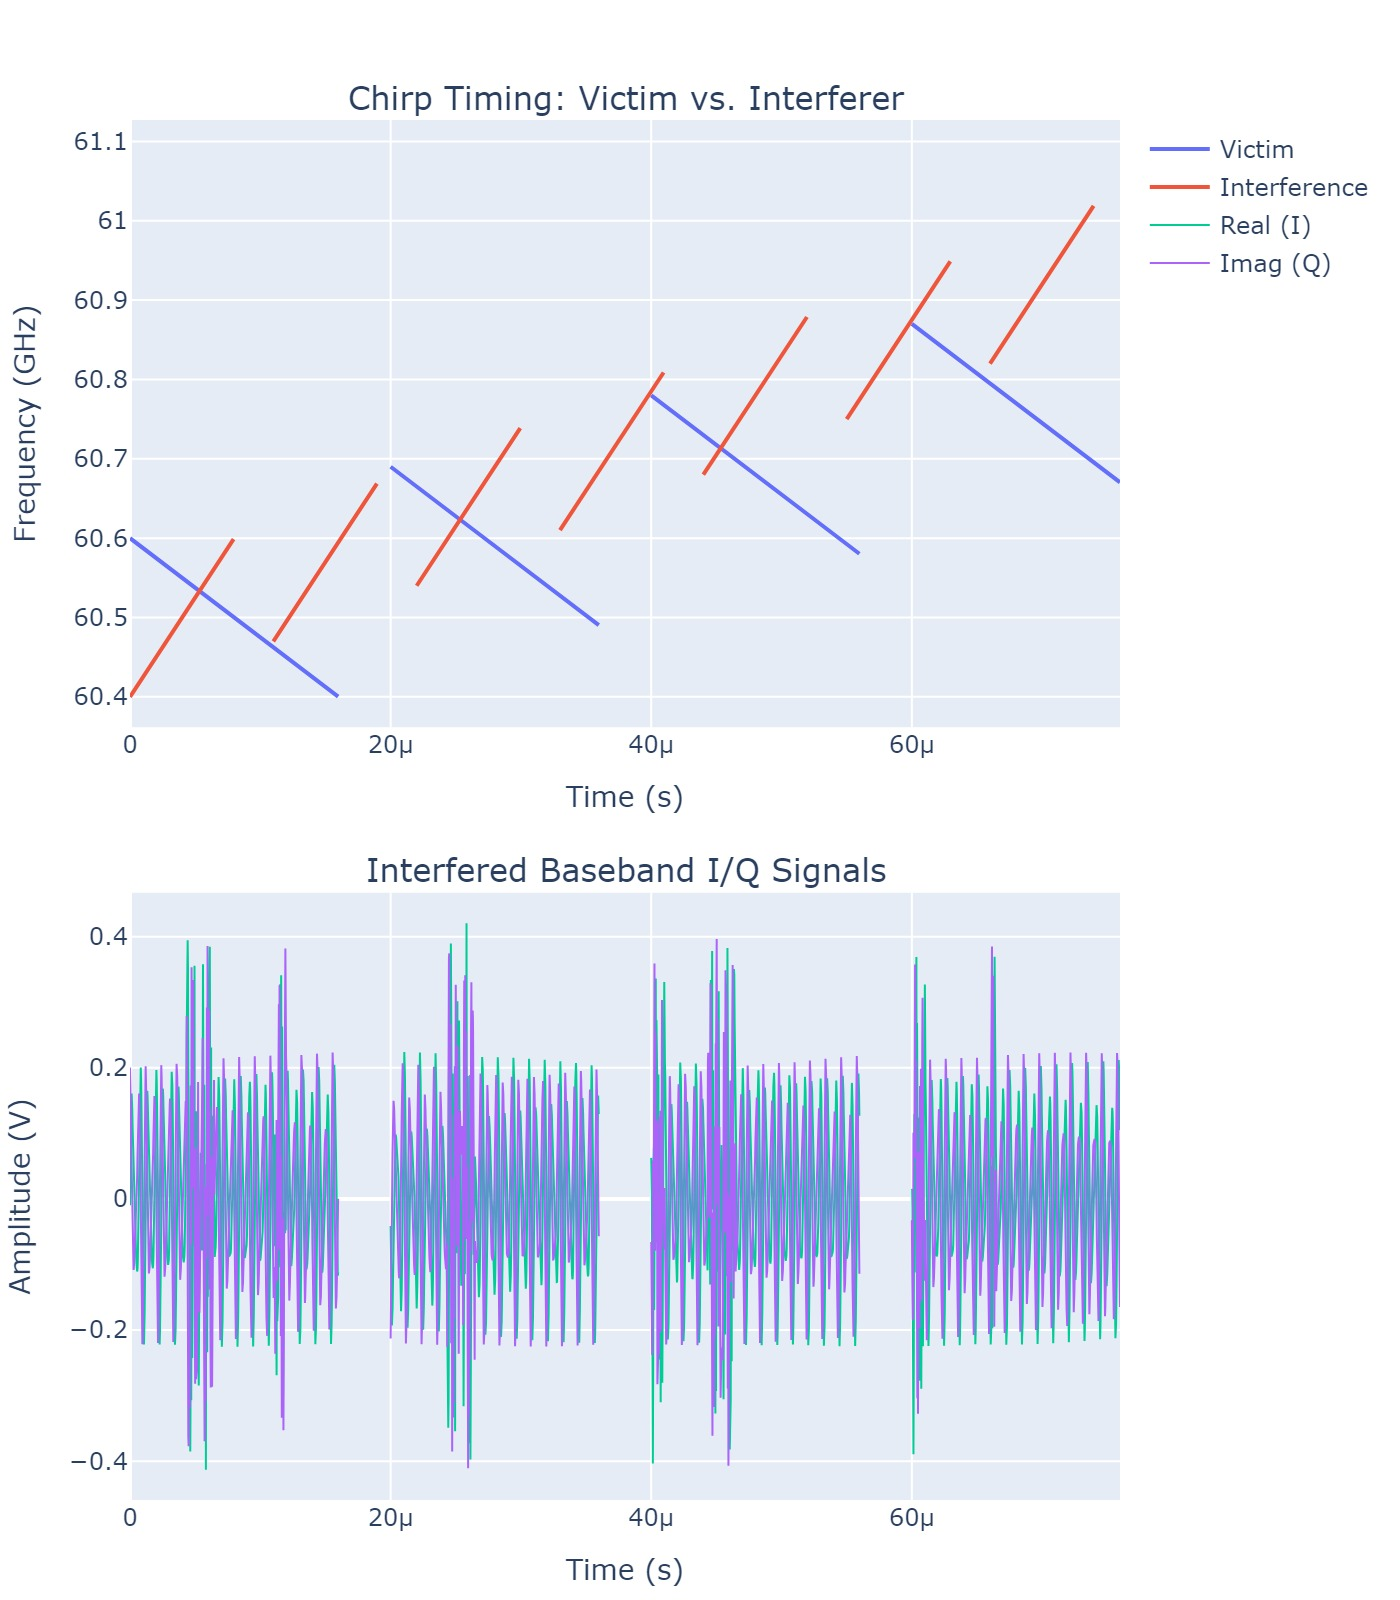

In [6]:
# Create two-panel figure
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Chirp Timing: Victim vs. Interferer", "Interfered Baseband I/Q Signals"),
    vertical_spacing=0.12,
)

### Panel 1: Victim Radar Chirps (Time-Frequency) ###

# Plot victim radar chirps (4 down-chirps with frequency hopping)
for idx in range(0, radar.radar_prop["transmitter"].waveform_prop["pulses"]):
    freq_axis = (
        np.linspace(
            radar.radar_prop["transmitter"].waveform_prop["f"][0],
            radar.radar_prop["transmitter"].waveform_prop["f"][1],
            radar.sample_prop["samples_per_pulse"],
            endpoint=False,
        )
        / 1e9
        + f_offset_vit[idx] / 1e9
    )
    
    fig.add_trace(
        go.Scatter(
            x=timestamp[0, idx, :],
            y=freq_axis,
            line=dict(color=px.colors.qualitative.Plotly[0], width=2),
            name="Victim",
            showlegend=(idx == 0),
        ),
        row=1,
        col=1,
    )

### Panel 1: Interferer Radar Chirps (Time-Frequency) ###

# Plot interferer radar chirps (8 up-chirps with frequency hopping)
for idx in range(0, int_radar.radar_prop["transmitter"].waveform_prop["pulses"]):
    freq_axis = (
        np.linspace(
            int_radar.radar_prop["transmitter"].waveform_prop["f"][0],
            int_radar.radar_prop["transmitter"].waveform_prop["f"][1],
            int_radar.sample_prop["samples_per_pulse"],
            endpoint=False,
        )
        / 1e9
        + f_offset_int[idx] / 1e9
    )
    
    fig.add_trace(
        go.Scatter(
            x=int_radar.time_prop["timestamp"][0, idx, :],
            y=freq_axis,
            line=dict(color=px.colors.qualitative.Plotly[1], width=2),
            name="Interference",
            showlegend=(idx == 0),
        ),
        row=1,
        col=1,
    )

### Panel 2: Interfered Baseband I/Q Signals ###

# Plot baseband I/Q for all victim chirps
for idx in range(0, radar.radar_prop["transmitter"].waveform_prop["pulses"]):
    fig.add_trace(
        go.Scatter(
            x=timestamp[0, idx, :],
            y=np.real(interf_bb[0, idx, :]),
            line=dict(color=px.colors.qualitative.Plotly[2], width=1),
            name="Real (I)",
            showlegend=(idx == 0),
        ),
        row=2,
        col=1,
    )
    
    fig.add_trace(
        go.Scatter(
            x=timestamp[0, idx, :],
            y=np.imag(interf_bb[0, idx, :]),
            line=dict(color=px.colors.qualitative.Plotly[3], width=1),
            name="Imag (Q)",
            showlegend=(idx == 0),
        ),
        row=2,
        col=1,
    )

### Configure Plot Layout ###

fig.update_xaxes(title_text="Time (s)", range=[0, timestamp[0, 3, -1]], row=1, col=1)
fig.update_yaxes(title_text="Frequency (GHz)", row=1, col=1)

fig.update_xaxes(title_text="Time (s)", range=[0, timestamp[0, 3, -1]], row=2, col=1)
fig.update_yaxes(title_text="Amplitude (V)", row=2, col=1)

fig.update_layout(
    height=800,
    margin=dict(l=10, r=10, b=10, t=60),
    hovermode='x unified',
)

show(fig)

## Analysis: Interference Correlation

**Key Observations:**

Interference corruption is clearly visible in the baseband when victim and interferer chirps overlap temporally and spectrally:

**Temporal Overlap:**
- Interferer has shorter PRP (11 μs) and transmits more frequently (8 chirps vs. 4)
- Multiple interferer chirps can collide with a single victim chirp
- Clean periods occur when no temporal overlap exists

**Spectral Overlap:**
- Both radars operate in 60.4-60.6 GHz band (200 MHz)
- Frequency hopping reduces collision probability but doesn't eliminate it
- When hopped frequencies overlap during temporal collision → strong interference

**Baseband Corruption Pattern:**
- **Amplitude spikes**: Sudden increases during interference
- **Phase distortion**: Random phase from unsynchronized interferer
- **Intermittent nature**: Not continuous, depends on chirp timing

**Mitigation Implications:**
1. **Detection**: Amplitude threshold can identify corrupted samples
2. **Blanking**: Zero out or interpolate through corruption
3. **Frequency diversity**: Partially helps but incomplete protection
4. **Statistical methods**: CFAR with interference rejection

## Summary

This example demonstrated mutual radar interference modeling:

- **Radar-to-radar interference** is stronger than target returns (1/R² vs. 1/R⁴)
- **Victim-interferer scenario** models two automotive radars facing each other
- **Frequency hopping** provides partial mitigation but doesn't eliminate interference
- **Temporal and spectral overlap** required for interference corruption
- **Baseband corruption** shows amplitude spikes during chirp collisions
- **Mitigation strategies** include detection, blanking, frequency diversity, and robust processing

### Things to Try

| Experiment | What to Change | What to Observe |
|------------|----------------|-----------------|
| PRF variations | Change victim/interferer PRP: 10, 15, 30 μs | Collision pattern changes |
| Frequency hopping | Increase hop size: 100, 200, 500 MHz | Mitigation effectiveness |
| Chirp direction | Both up-chirps or both down-chirps | Beat frequency differences |
| Spatial geometry | Vary distance: 10, 50, 100 m; angles: 45°, 90° | Antenna pattern effects |
| Power levels | Increase interferer power: 20, 25, 30 dBm | Interference-to-signal ratio |
| Pulse width | Match pulse widths or large differences | Collision probability |
| Multi-interferer | Add 2nd, 3rd interfering radars | Cumulative interference effects |

### Resources

- [RadarSimPy Documentation](https://radarsimx.com)
- [RadarSimPy Simulator Module](https://radarsimx.github.io/radarsimpy/simulator.html)